# AutoML Framework — Diabetes, Iris & Loan Datasets

This notebook demonstrates a simple **AutoML framework** that:

1. Takes any tabular classification dataset as input
2. Automatically preprocesses it (missing-value imputation, encoding, scaling)
3. Trains 5 candidate models: Logistic Regression, Random Forest, Decision Tree, SVM, KNN
4. Compares their accuracy
5. Automatically selects the best model
6. Generates a summary report

We run this pipeline on three different datasets — **Diabetes**, **Iris**, and **Loan** —
to show that the same engine generalizes across problems with different sizes, feature
types (numeric vs. categorical), and number of classes.


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from data_preprocessing import DATASET_CONFIGS, preprocess
from automl import run_automl, get_candidate_models


## 1. Peek at the raw datasets

In [2]:
diabetes_df = pd.read_csv("../data/diabetes.csv")
print("Diabetes:", diabetes_df.shape)
diabetes_df.head()


Diabetes: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
iris_df = pd.read_csv("../data/iris.csv")
print("Iris:", iris_df.shape)
iris_df.head()


Iris: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
loan_df = pd.read_csv("../data/loan.csv")
print("Loan:", loan_df.shape)
loan_df.head()


Loan: (491, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


## 2. The AutoML Workflow

```
Input Dataset
      |
Data Preprocessing        <- data_preprocessing.py
      |
Train Multiple Models      <- Logistic Regression, Random Forest,
      |                        Decision Tree, SVM, KNN
Compare Accuracy
      |
Select Best Model
      |
Generate Report
```

Each dataset is registered in `DATASET_CONFIGS` with its target column,
any identifier columns to drop, and any columns where `0` really means
"missing". The same `run_automl()` function then handles all three
datasets without any dataset-specific code.

In [5]:
for name, config in DATASET_CONFIGS.items():
    print(f"{name:10s} -> target='{config['target']}', drop_cols={config['drop_cols']}")


diabetes   -> target='Outcome', drop_cols=[]
iris       -> target='species', drop_cols=[]
loan       -> target='Loan_Status', drop_cols=['Loan_ID']


## 3. Run AutoML on the Diabetes dataset

In [6]:
diabetes_result = run_automl("diabetes")
print("\nBest Model =", diabetes_result["best_model"])
print(f"Accuracy = {diabetes_result['best_accuracy']*100:.1f}%")


  Logistic Regression    accuracy = 0.7078


  Random Forest          accuracy = 0.7468
  Decision Tree          accuracy = 0.7143
  SVM                    accuracy = 0.7403
  KNN                    accuracy = 0.7273
  -> Best Model = Random Forest | Accuracy = 74.7%
              precision    recall  f1-score   support

           0       0.77      0.86      0.82       100
           1       0.67      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154




Best Model = Random Forest
Accuracy = 74.7%


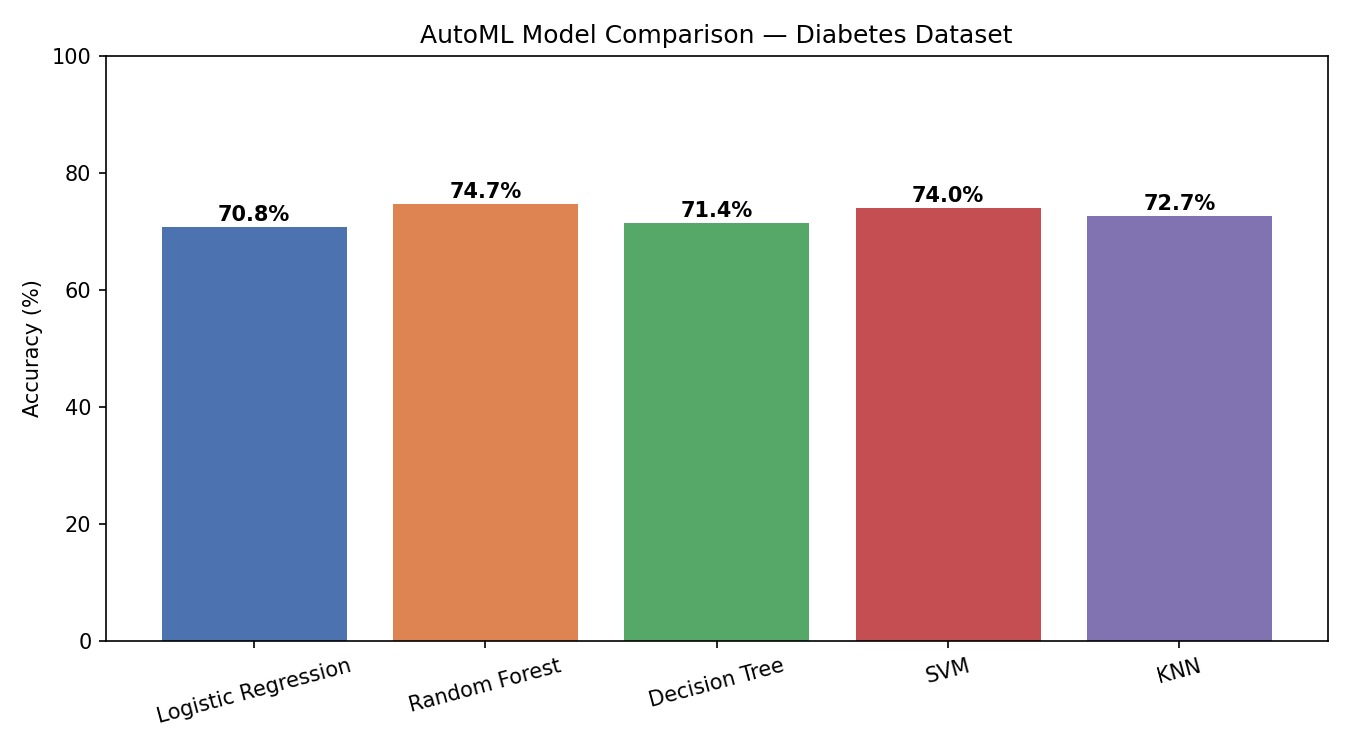

In [7]:
display(Image(diabetes_result["chart_path"]))


## 4. Run AutoML on the Iris dataset

In [8]:
iris_result = run_automl("iris")
print("\nBest Model =", iris_result["best_model"])
print(f"Accuracy = {iris_result['best_accuracy']*100:.1f}%")


  Logistic Regression    accuracy = 0.9333


  Random Forest          accuracy = 0.9000
  Decision Tree          accuracy = 0.9000
  SVM                    accuracy = 0.9667
  KNN                    accuracy = 0.9667
  -> Best Model = SVM | Accuracy = 96.7%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Best Model = SVM
Accuracy = 96.7%


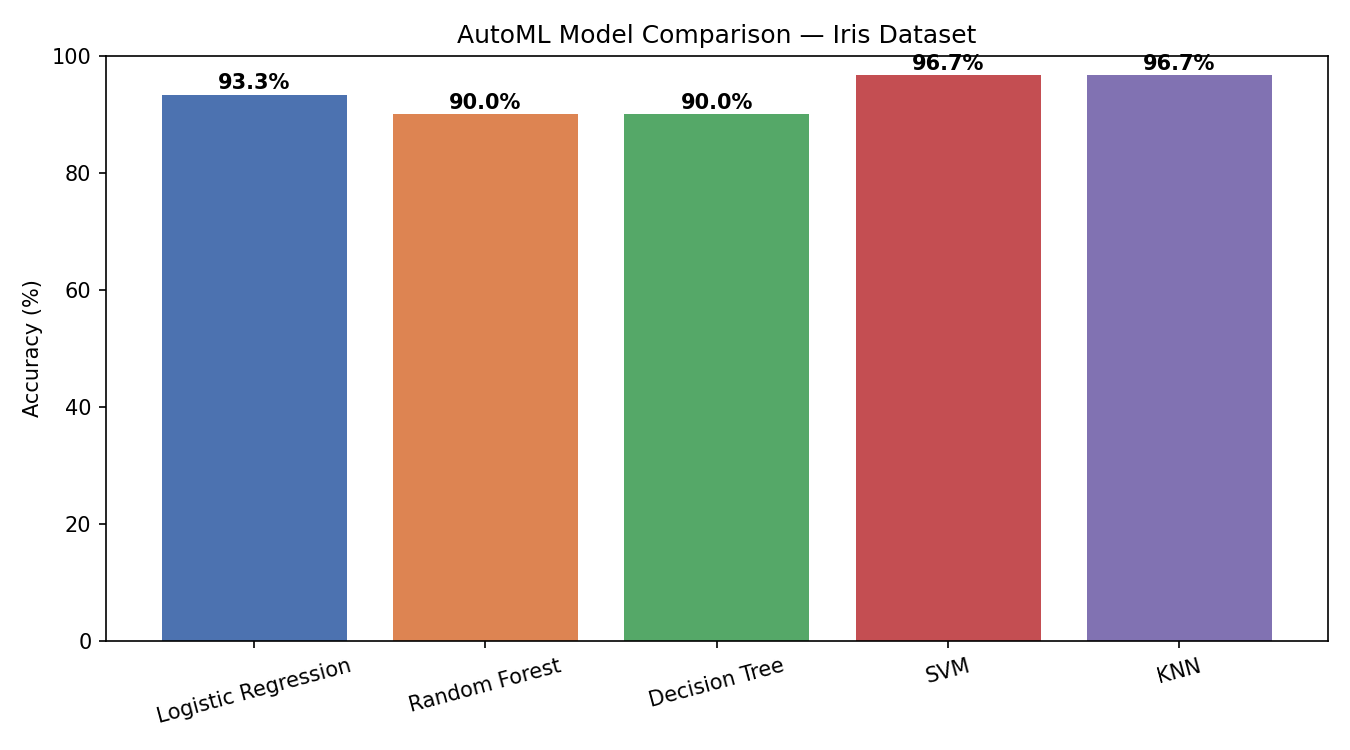

In [9]:
display(Image(iris_result["chart_path"]))


## 5. Run AutoML on the Loan dataset

In [10]:
loan_result = run_automl("loan")
print("\nBest Model =", loan_result["best_model"])
print(f"Accuracy = {loan_result['best_accuracy']*100:.1f}%")


  Logistic Regression    accuracy = 0.8283


  Random Forest          accuracy = 0.8384
  Decision Tree          accuracy = 0.7879
  SVM                    accuracy = 0.8283
  KNN                    accuracy = 0.8182
  -> Best Model = Random Forest | Accuracy = 83.8%
              precision    recall  f1-score   support

           0       0.85      0.57      0.68        30
           1       0.84      0.96      0.89        69

    accuracy                           0.84        99
   macro avg       0.84      0.76      0.79        99
weighted avg       0.84      0.84      0.83        99




Best Model = Random Forest
Accuracy = 83.8%


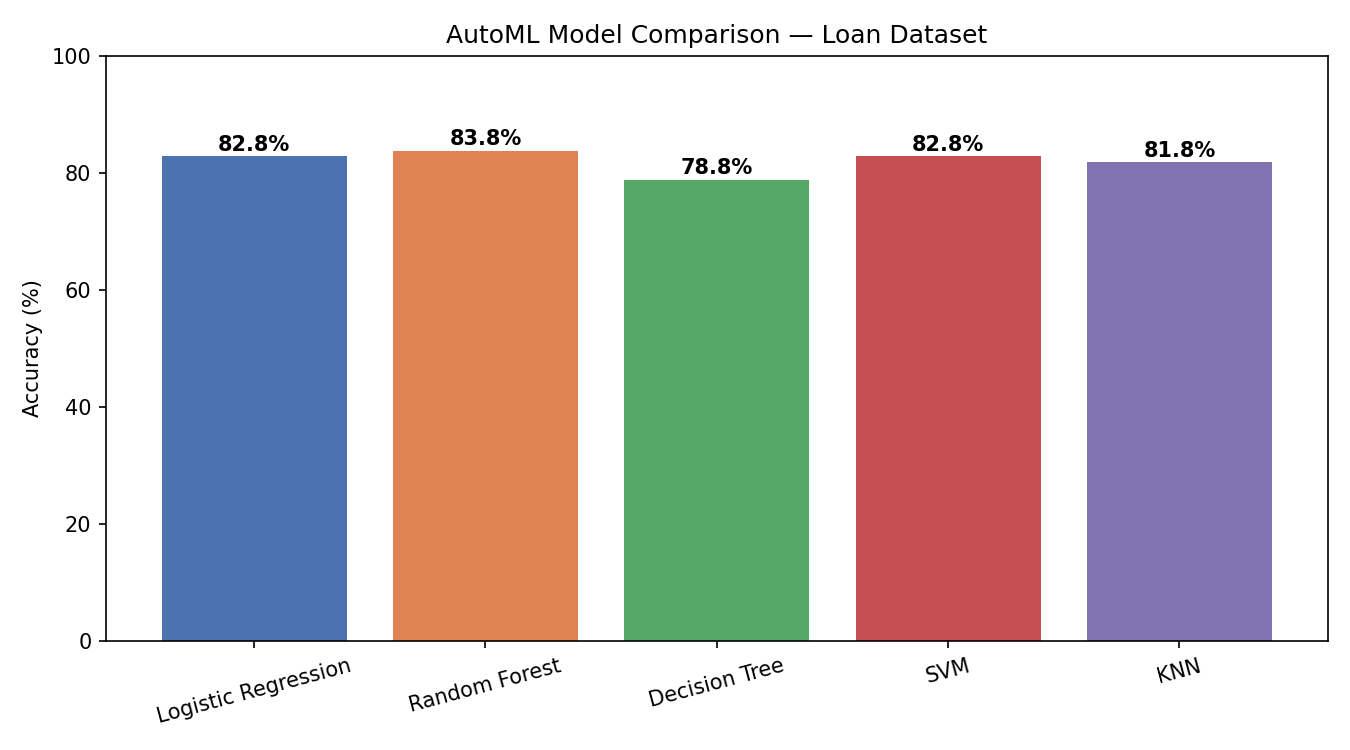

In [11]:
display(Image(loan_result["chart_path"]))


## 6. Final Summary — Best Model per Dataset

In [12]:
summary = {
    "diabetes": diabetes_result,
    "iris": iris_result,
    "loan": loan_result,
}

for name, result in summary.items():
    print(f"Dataset: {name}")
    print(f"Best Model = {result['best_model']}")
    print(f"Accuracy = {result['best_accuracy']*100:.1f}%")
    print("-" * 30)


Dataset: diabetes
Best Model = Random Forest
Accuracy = 74.7%
------------------------------
Dataset: iris
Best Model = SVM
Accuracy = 96.7%
------------------------------
Dataset: loan
Best Model = Random Forest
Accuracy = 83.8%
------------------------------


## Conclusion

The AutoML engine successfully generalized across three very different
datasets:

- **Diabetes** (numeric features, class imbalance, missing-as-zero values)
- **Iris** (small, clean, multi-class, purely numeric)
- **Loan** (mixed numeric + categorical features, real missing values)

In each case, the framework automatically handled preprocessing,
trained all 5 candidate models, compared their accuracy, and selected
the best one — with no dataset-specific code required beyond the
initial configuration entry.

The winning models for each dataset are saved under `outputs/` as
`best_model_<dataset>.pkl`, and a consolidated report is available at
`outputs/automl_report.txt` / `outputs/automl_report.json`.
